In [13]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [84]:
df=pd.read_csv("Support_Vector _Regression_dataset.csv")

In [86]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## Data Cleaning

In [89]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [91]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


## Feature Engineering

In [100]:
Male=pd.get_dummies(df["sex"],drop_first=True).astype(int)
df=pd.concat([df,Male],axis=1)
df.head()

,age,sex,bmi,children,smoker,region,charges,Smoker,male
0,19,female,27.900,0,yes,southwest,16884.92400,1,0
1,18,male,33.770,1,no,southeast,1725.55230,0,1
2,28,male,33.000,3,no,southeast,4449.46200,0,1
3,33,male,22.705,0,no,northwest,21984.47061,0,1
4,32,male,28.880,0,no,northwest,3866.85520,0,1


In [94]:
Smoker=pd.get_dummies(df["smoker"],drop_first=True).astype(int)
df=pd.concat([df,Smoker],axis=1)
df.head()

,age,sex,bmi,children,smoker,region,charges,yes
0,19,female,27.900,0,yes,southwest,16884.92400,1
1,18,male,33.770,1,no,southeast,1725.55230,0
2,28,male,33.000,3,no,southeast,4449.46200,0
3,33,male,22.705,0,no,northwest,21984.47061,0
4,32,male,28.880,0,no,northwest,3866.85520,0


In [96]:
df=df.rename({"yes":"Smoker"},axis=1)

In [102]:
df.head()

,age,sex,bmi,children,smoker,region,charges,Smoker,male
0,19,female,27.900,0,yes,southwest,16884.92400,1,0
1,18,male,33.770,1,no,southeast,1725.55230,0,1
2,28,male,33.000,3,no,southeast,4449.46200,0,1
3,33,male,22.705,0,no,northwest,21984.47061,0,1
4,32,male,28.880,0,no,northwest,3866.85520,0,1


In [104]:
df["region"].unique()

array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object)

In [113]:
Region=pd.get_dummies(df["region"],drop_first=True).astype(int)
df=pd.concat([df,Region],axis=1)
df.head()

,age,sex,bmi,children,smoker,region,charges,Smoker,male,northwest,southeast,southwest
0,19,female,27.900,0,yes,southwest,16884.92400,1,0,0,0,1
1,18,male,33.770,1,no,southeast,1725.55230,0,1,0,1,0
2,28,male,33.000,3,no,southeast,4449.46200,0,1,0,1,0
3,33,male,22.705,0,no,northwest,21984.47061,0,1,1,0,0
4,32,male,28.880,0,no,northwest,3866.85520,0,1,1,0,0


## Exploratory Analysis

### Distribution of sex parameter

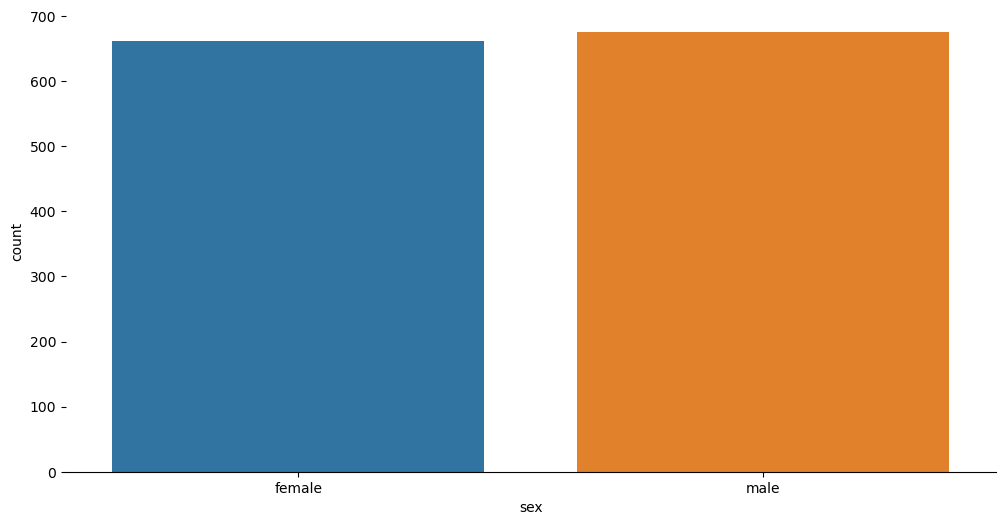

In [115]:
plt.figure(figsize=(12,6))
sns.countplot(x="sex",data=df)
sns.despine(left=True)

### Reln of smoking and gender to charges

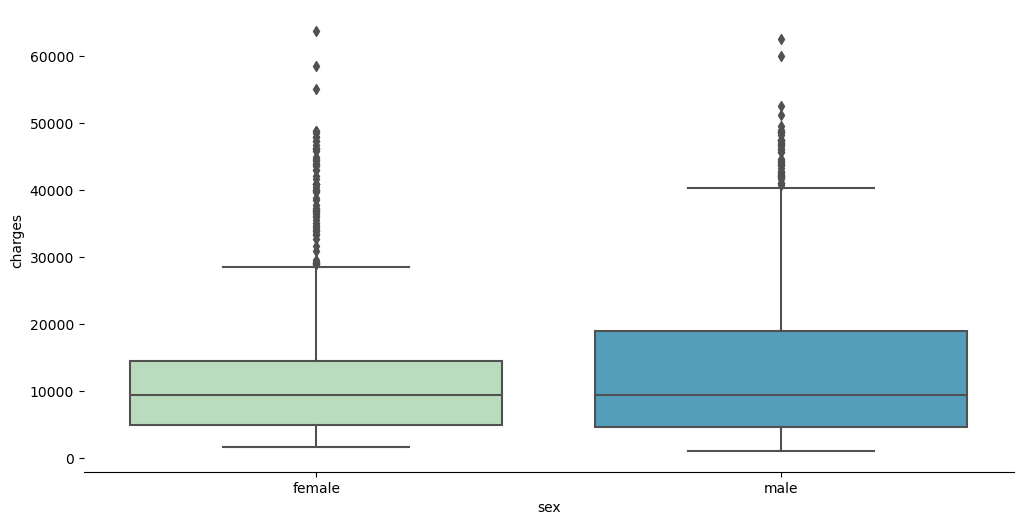

In [119]:
plt.figure(figsize=(12,6))
sns.boxplot(x="sex",y="charges",data=df,palette="GnBu")
sns.despine(left=True)

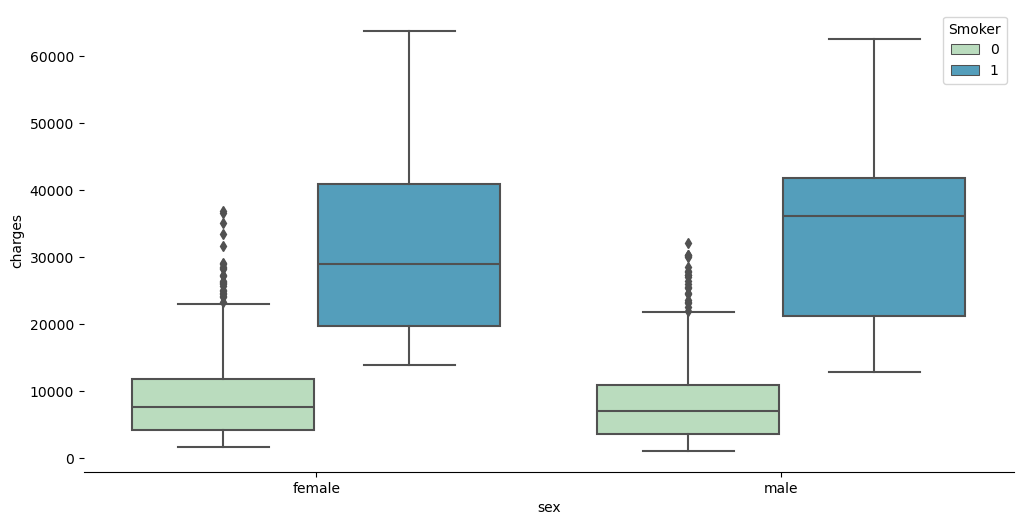

In [121]:
plt.figure(figsize=(12,6))
sns.boxplot(x="sex",y="charges",data=df,palette="GnBu",hue="Smoker")
sns.despine(left=True)

<Axes: xlabel='age', ylabel='charges'>

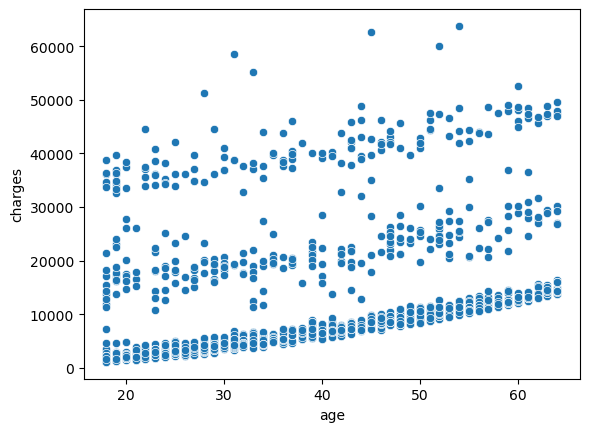

In [123]:
sns.scatterplot(x="age",y="charges",data=df)

<Axes: xlabel='age', ylabel='charges'>

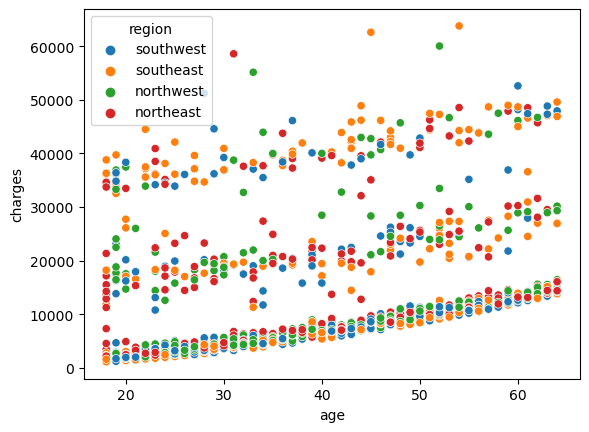

In [125]:
sns.scatterplot(x="age",y="charges",data=df,hue="region")

<Axes: xlabel='age', ylabel='charges'>

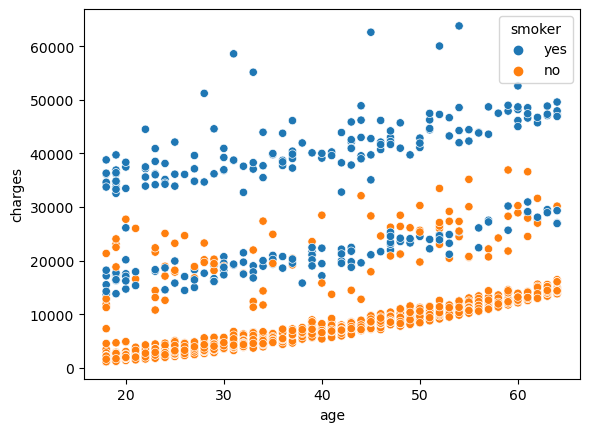

In [127]:
sns.scatterplot(x="age",y="charges",data=df,hue="smoker")

<Axes: xlabel='bmi', ylabel='charges'>

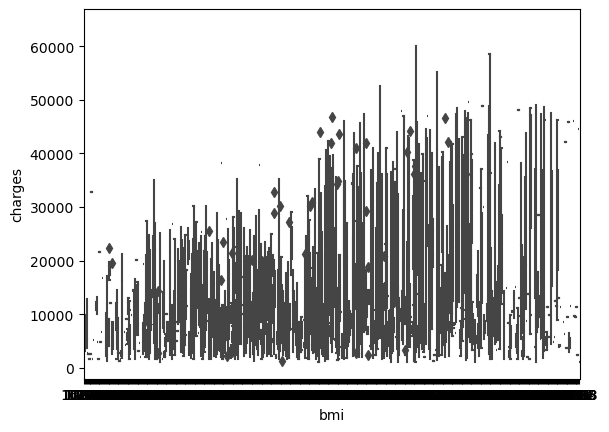

In [137]:
sns.boxplot(x="bmi",y="charges",data=df)

C:\Users\Asus\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Asus\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='bmi', ylabel='charges'>

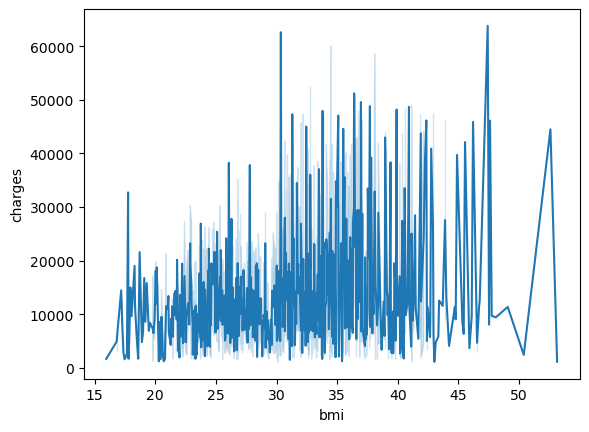

In [141]:
sns.lineplot(x="bmi",y="charges",data=df)

<Axes: xlabel='bmi', ylabel='charges'>

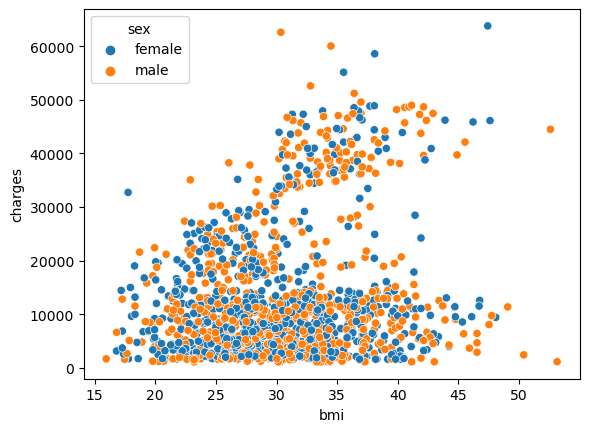

In [145]:
sns.scatterplot(x="bmi",y="charges",data=df,hue="sex")

<Axes: xlabel='bmi', ylabel='charges'>

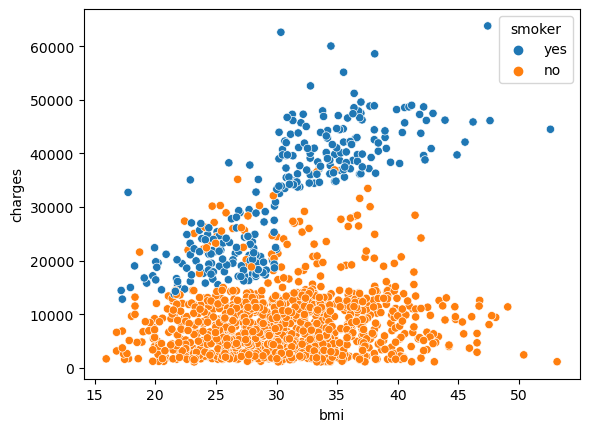

In [147]:
sns.scatterplot(x="bmi",y="charges",data=df,hue="smoker")

<Axes: xlabel='bmi', ylabel='charges'>

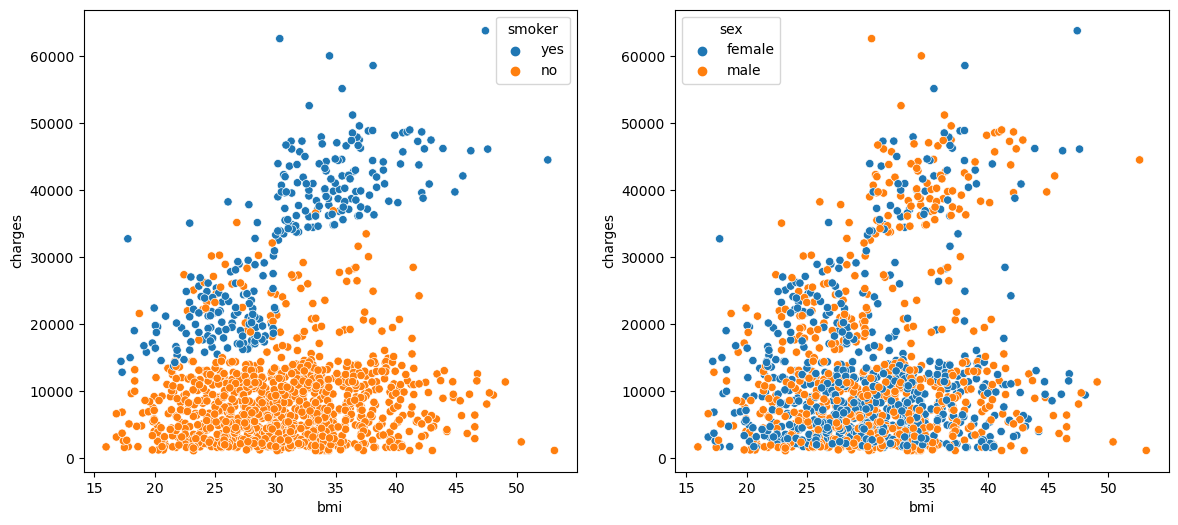

In [151]:
fig,ax=plt.subplots(nrows=1,ncols=2,figsize=(14,6))
sns.scatterplot(x="bmi",y="charges",data=df,hue="smoker",ax=ax[0])
sns.scatterplot(x="bmi",y="charges",data=df,hue="sex",ax=ax[1])

In [155]:
df.drop(["sex","smoker","region"],axis=1,inplace=True)

In [157]:
df.head()

,age,bmi,children,charges,Smoker,male,northwest,southeast,southwest
0,19,27.900,0,16884.92400,1,0,0,0,1
1,18,33.770,1,1725.55230,0,1,0,1,0
2,28,33.000,3,4449.46200,0,1,0,1,0
3,33,22.705,0,21984.47061,0,1,1,0,0
4,32,28.880,0,3866.85520,0,1,1,0,0


<Axes: >

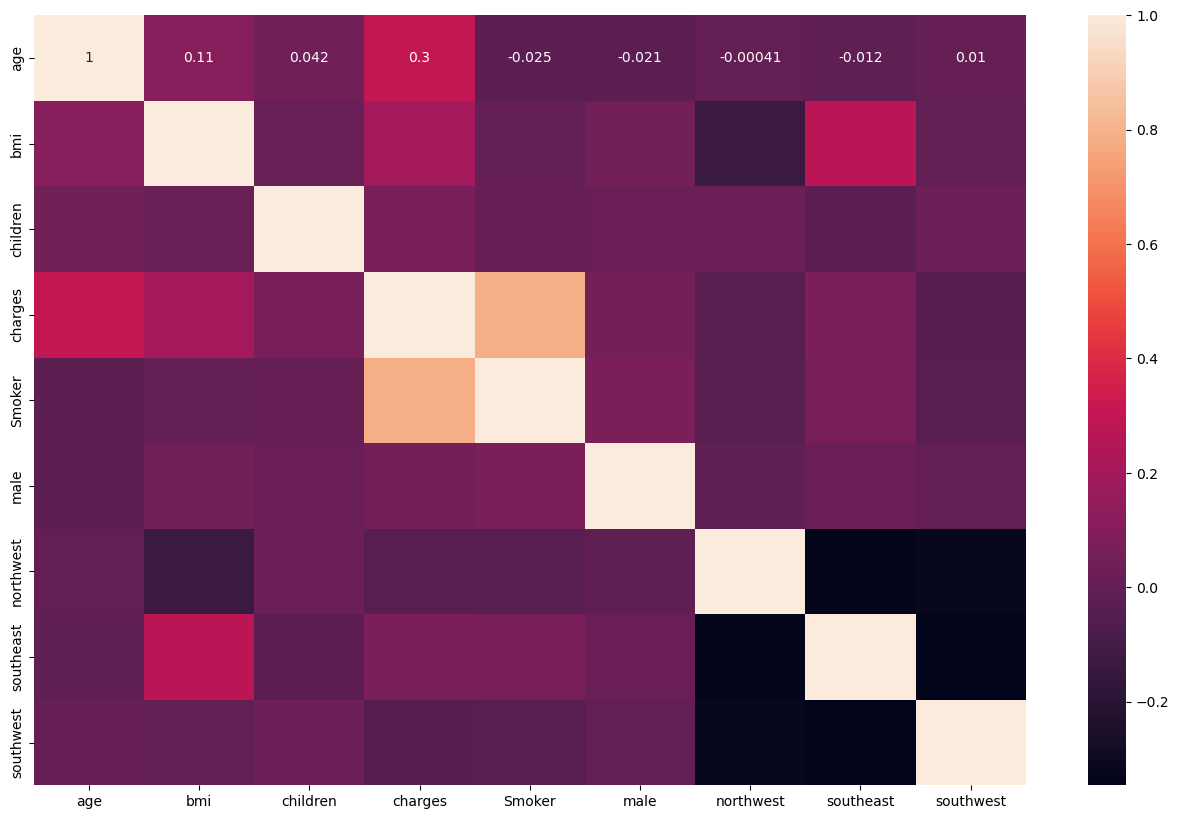

In [175]:
plt.figure(figsize=(16,10))
sns.heatmap(df.corr(),annot=True)

In [177]:
df.corr()

,age,bmi,children,charges,Smoker,male,northwest,southeast,southwest
age,1.000000,0.109272,0.042469,0.299008,-0.025019,-0.020856,-0.000407,-0.011642,0.010016
bmi,0.109272,1.000000,0.012759,0.198341,0.003750,0.046371,-0.135996,0.270025,-0.006205
children,0.042469,0.012759,1.000000,0.067998,0.007673,0.017163,0.024806,-0.023066,0.021914
charges,0.299008,0.198341,0.067998,1.000000,0.787251,0.057292,-0.039905,0.073982,-0.043210
Smoker,-0.025019,0.003750,0.007673,0.787251,1.000000,0.076185,-0.036945,0.068498,-0.036945
male,-0.020856,0.046371,0.017163,0.057292,0.076185,1.000000,-0.011156,0.017117,-0.004184
northwest,-0.000407,-0.135996,0.024806,-0.039905,-0.036945,-0.011156,1.000000,-0.346265,-0.320829
southeast,-0.011642,0.270025,-0.023066,0.073982,0.068498,0.017117,-0.346265,1.000000,-0.346265
southwest,0.010016,-0.006205,0.021914,-0.043210,-0.036945,-0.004184,-0.320829,-0.346265,1.000000


### Splitting the Data

In [182]:
x=df.drop("charges",axis=1)
y=df["charges"]

In [196]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.4,random_state=23)

In [198]:
x_train.shape

(802, 8)

In [200]:
x_test.shape

(536, 8)

### Scaling the Data

In [203]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [207]:
scaled_x_train=scaler.fit_transform(x_train)
scaled_x_test=scaler.transform(x_test)

In [209]:
scaled_x_train

array([[ 0.95449827,  0.90374388,  1.58639532, ..., -0.5744707 ,
        -0.60712493,  1.80719602],
       [ 0.67262121, -1.22332008,  0.76290726, ...,  1.74073282,
        -0.60712493, -0.55334341],
       [-0.80723332,  0.39654532, -0.88406885, ..., -0.5744707 ,
        -0.60712493,  1.80719602],
       ...,
       [-0.73676406, -0.83975117,  2.40988337, ..., -0.5744707 ,
        -0.60712493,  1.80719602],
       [ 0.95449827,  0.5082875 , -0.88406885, ..., -0.5744707 ,
        -0.60712493, -0.55334341],
       [ 0.46121342,  0.44805767, -0.06058079, ..., -0.5744707 ,
        -0.60712493, -0.55334341]])

## Support Vector Regression Model

In [214]:
from sklearn.svm import SVR
regressor=SVR()
regressor.fit(scaled_x_train,y_train)

SVR()

In [216]:
predict=regressor.predict(scaled_x_test)

In [218]:
predict.shape

(536,)

In [220]:
y_test.shape

(536,)

In [222]:
predict[:10]

array([9549.40014166, 9496.17773754, 9571.4441682 , 9535.93179646,
       9512.38474836, 9522.03107046, 9583.5112138 , 9507.07366851,
       9547.51888175, 9575.59916005])

In [224]:
y_test[:10]

918     13041.92100
755      5031.26955
207     20984.09360
520     25656.57526
695      3201.24515
567      7256.72310
956     41999.52000
353     12404.87910
25      14001.13380
1240    47269.85400
Name: charges, dtype: float64